In [3]:
%pip install requests pandas beautifulsoup4 lxml openpyxl xlrd

Note: you may need to restart the kernel to use updated packages.


In [4]:
from io import StringIO
import requests
import pandas as pd
from bs4 import BeautifulSoup
print("Libraries loaded")

Libraries loaded


In [6]:
HEADERS = {"User-Agent": "Mozilla/5.0"}

In [7]:
PROD_URL = "https://petrocom.gov.gh/production-volume/"

In [9]:
resp = requests.get(PROD_URL, headers=HEADERS, timeout=30)

In [10]:
print("Status:", resp.status_code)

Status: 406


In [11]:
print("Page size:", len(resp.text))

Page size: 226


In [12]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

In [13]:
resp = requests.get(PROD_URL, headers=HEADERS, timeout=30)
print("Status:", resp.status_code)
print("Page size:", len(resp.text))

Status: 200
Page size: 328557


In [14]:
print(resp.text)

<!DOCTYPE html>
<html lang="en-US" class="no-js no-svg">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<!-- browser-theme-color for WordPress -->
<meta name="theme-color" content="#1b3d7b">
<meta name="msapplication-navbutton-color" content="#1b3d7b">
<meta name="mobile-web-app-capable" content="yes">
<meta name="apple-mobile-web-app-status-bar-style" content="black-translucent">
<link rel="profile" href="https://gmpg.org/xfn/11">
<title>Production Volume &#8211; PETROLEUM COMMISSION GHANA</title>
<meta name='robots' content='max-image-preview:large' />
<link rel='preconnect' href='//i0.wp.com' />
<link href='https://fonts.gstatic.com' crossorigin rel='preconnect' />
<link rel="alternate" type="application/rss+xml" title="PETROLEUM COMMISSION GHANA &raquo; Feed" href="https://petrocom.gov.gh/feed/" />
<link rel="alternate" type="application/rss+xml" title="PETROLEUM COMMISSION GHANA &raquo; Comments Feed" href="https://petrocom.gov.g

In [15]:
tables = pd.read_html(StringIO(resp.text))
print("Tables found:", len(tables))
for i, t in enumerate(tables):
    print(i, t.shape, list(t.columns)[:3])

Tables found: 6
0 (12, 8) ['Period', 'Oil  Production (bbl/d)', 'Gas  Production (MMscf/d)']
1 (15, 8) ['Period', 'Lifiting  Party', 'Quantity of  Oil Lifted (bbl)']
2 (13, 9) ['Period', 'Oil  Production (bbl/d)', 'Gas  Production (MMscf/d)']
3 (4, 3) ['Period', 'Lifting  Party', 'Quantity  Lifted (bbl)']
4 (12, 8) ['Period', 'Oil  Production (bbl/d)', 'Associated  Gas Production (MMscf/d)']
5 (8, 3) ['Period', 'Lifting  Party', 'Quantity  Lifted (bbl)']


In [16]:
tables = pd.read_html(StringIO(resp.text))
print("Tables found:", len(tables))
for i, t in enumerate(tables):
    print(i, t.shape, list(t.columns)[:3])

Tables found: 6
0 (12, 8) ['Period', 'Oil  Production (bbl/d)', 'Gas  Production (MMscf/d)']
1 (15, 8) ['Period', 'Lifiting  Party', 'Quantity of  Oil Lifted (bbl)']
2 (13, 9) ['Period', 'Oil  Production (bbl/d)', 'Gas  Production (MMscf/d)']
3 (4, 3) ['Period', 'Lifting  Party', 'Quantity  Lifted (bbl)']
4 (12, 8) ['Period', 'Oil  Production (bbl/d)', 'Associated  Gas Production (MMscf/d)']
5 (8, 3) ['Period', 'Lifting  Party', 'Quantity  Lifted (bbl)']


In [17]:
soup = BeautifulSoup(resp.text, "html.parser")
excel_links = {}
for a in soup.find_all("a", attrs={"data-downloadurl": True}):
    card = a.find_parent("div", class_="media")
    title = card.find("h3").get_text(strip=True)
    excel_links[title] = a["data-downloadurl"]
for title, url in excel_links.items():
    print(title, "->", url)

2025 Fields Production Data -> https://petrocom.gov.gh/download/2025-fields-production-data/?wpdmdl=24377&refresh=6ab63fba3d8831790328762
2024 Fields Production Data -> https://petrocom.gov.gh/download/2023-fields-production-data-2/?wpdmdl=23866&refresh=6ab63fba84c221790328762


In [18]:
import os, re
os.makedirs("raw", exist_ok=True)
dl_headers = dict(HEADERS, Referer=PROD_URL)
saved_files = []
for title, url in excel_links.items():
    r = requests.get(url, headers=dl_headers, timeout=60)
    cd = r.headers.get("Content-Disposition", "")
    match = re.search(r'filename="?([^";]+)"?', cd)
    fname = match.group(1) if match else title.replace(" ", "_") + ".xlsx"
    path = os.path.join("raw", fname)
    with open(path, "wb") as f:
        f.write(r.content)
    saved_files.append(path)
    print(title, "| status", r.status_code, "| type", r.headers.get("Content-Type"), "| KB", round(len(r.content) / 1024, 1), "|", path)

2025 Fields Production Data | status 200 | type application/vnd.openxmlformats-officedocument.spreadsheetml.sheet | KB 583.2 | raw\2025-Fields-Production-Data-for-Website.xlsx
2024 Fields Production Data | status 200 | type application/vnd.openxmlformats-officedocument.spreadsheetml.sheet | KB 583.1 | raw\2024_Fields_Production_Data.xlsx


In [19]:
for path in saved_files:
    xl = pd.ExcelFile(path)
    print(path)
    print("   Sheets:", xl.sheet_names)

raw\2025-Fields-Production-Data-for-Website.xlsx
   Sheets: ['JUBILEE FIELD', 'TEN FIELD', 'OCTP FIELD']
raw\2024_Fields_Production_Data.xlsx
   Sheets: ['JUBILEE FIELD', 'TEN FIELD', 'OCTP FIELD']


In [20]:
import hashlib
for path in saved_files:
    with open(path, "rb") as f:
        print(path, hashlib.md5(f.read()).hexdigest())

raw\2025-Fields-Production-Data-for-Website.xlsx 1d7fa562d28c6729b842655d77993e26
raw\2024_Fields_Production_Data.xlsx 8ac63a422a9cbcf3cfa283559cd4ec80


In [21]:
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 250)
raw_jub = pd.read_excel(saved_files[0], sheet_name="JUBILEE FIELD", header=None)
print("Shape:", raw_jub.shape)
raw_jub.head(20)

Shape: (48, 8)


,0,1,2,3,4,5,6,7
0,Jubilee Production for the Year 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Period,Oil Production (bbl/d),Gas Production (MMscf/d),Gas Re-injected (MMscf/d),Fuel Gas (MMscf/d),Flared Gas (MMscf/d),Gas Exported to GNGC (MMscf/d),Gas Export to TEN (MMscf/d)
2,"January, 2025",77356.483871,206.707419,60.516452,11.910968,33.920968,100.359032,0
3,"February, 2025",74121.607143,199.348929,74.727857,10.383214,35.360357,78.8775,0
4,"*March, 2025",49026.645161,137.614194,29.65,7.282581,36.494516,64.186774,0
5,"*April, 2025",42395.7,136.518333,35.492667,6.974667,28.092333,60.273,5.685667
6,"May, 2025",61134.354839,207.260645,72.676452,12.27129,34.64129,86.679677,0
7,"June, 2025",62101.7,223.025667,73.278,10.514333,35.538333,103.695,0
8,"July, 2025",60958.290323,229.669355,73.770323,12.485806,30.242258,106.217097,0
9,"August, 2025",63609.096774,234.941613,142.98129,13.378387,21.494194,52.551613,0


In [22]:
print(raw_jub.iloc[16, 0])
raw_jub.iloc[18:48, 0:4]

*2 WEEKS PLANNED SHUTDOWN WINDOW (END OF MARCH TO EARLY APRIL)


,0,1,2,3
18,Jubilee Liftings for the Year 2025,NaN,NaN,NaN
19,Period,Lifiting Party,Quantity of Oil Lifted (bbl),NaN
20,2025-01-04 00:00:00,GHANA NATIONAL PETROLEUM CORPORATION,953322,NaN
21,2025-01-16 00:00:00,TGL AND PETROSA,957490,NaN
22,2025-01-29 00:00:00,KOSMOS ENERGY GHANA INVESTMENTS,959380,NaN
23,2025-02-10 00:00:00,TGL AND PETROSA,910438,NaN
24,2025-02-22 00:00:00,KOSMOS ENERGY GHANA HC,909020,NaN
25,2025-03-07 00:00:00,TGL AND PETROSA,906355,NaN
26,2025-03-21 00:00:00,GHANA GROUP,905549,NaN
27,2025-04-22 00:00:00,KOSMOS ENERGY GHANA INVESTMENTS,949813,NaN


In [23]:
def split_sheet(path, sheet, year):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    first_col = raw[0].astype(str).str.strip()
    header_rows = raw.index[first_col == "Period"].tolist()
    blocks = []
    for h in header_rows:
        end = h + 1
        while end < len(raw) and raw.iloc[end].notna().any() and str(raw.iloc[end, 0]).strip().upper() != "TOTAL":
            end += 1
        block = raw.iloc[h + 1:end].copy()
        block.columns = [str(c).replace("\n", " ").strip() for c in raw.iloc[h]]
        block = block.dropna(axis=1, how="all")
        block.insert(0, "Field", sheet.replace(" FIELD", "").strip().title())
        block.insert(1, "Year", year)
        blocks.append(block)
    return blocks

In [24]:
all_blocks = []
for path in saved_files:
    year = int(re.search(r"20\d\d", path).group())
    for sheet in pd.ExcelFile(path).sheet_names:
        blocks = split_sheet(path, sheet, year)
        print(year, sheet, "| tables found:", len(blocks), "| shapes:", [b.shape for b in blocks])
        all_blocks.append((year, sheet, blocks))

2025 JUBILEE FIELD | tables found: 2 | shapes: [(12, 10), (24, 5)]
2025 TEN FIELD | tables found: 2 | shapes: [(12, 10), (6, 5)]
2025 OCTP FIELD | tables found: 2 | shapes: [(12, 10), (10, 5)]
2024 JUBILEE FIELD | tables found: 2 | shapes: [(12, 10), (33, 5)]
2024 TEN FIELD | tables found: 2 | shapes: [(12, 10), (7, 5)]
2024 OCTP FIELD | tables found: 2 | shapes: [(12, 10), (10, 5)]


In [25]:
for year, sheet, blocks in all_blocks:
    print(year, sheet)
    print("   ", list(blocks[0].columns))

2025 JUBILEE FIELD
    ['Field', 'Year', 'Period', 'Oil Production (bbl/d)', 'Gas Production (MMscf/d)', 'Gas Re-injected (MMscf/d)', 'Fuel Gas (MMscf/d)', 'Flared Gas (MMscf/d)', 'Gas Exported to GNGC (MMscf/d)', 'Gas Export to TEN (MMscf/d)']
2025 TEN FIELD
    ['Field', 'Year', 'Period', 'Oil Production (bbl/d)', 'Gas Production (MMscf/d)', 'Gas Re-injected (MMscf/d)', 'Fuel Gas (MMscf/d)', 'Flared Gas (MMscf/d)', 'Gas Exported to GNGC (MMscf/d)', 'Gas imported to TEN from Jubilee (MMscf/d)']
2025 OCTP FIELD
    ['Field', 'Year', 'Period', 'Oil Production (bbl/d)', 'Associated Gas Production (MMscf/d)', 'Non - Asssociated Gas Production (MMscf/d)', 'Gas  Re-injected (MMscf/d)', 'Fuel  Gas (MMscf/d)', 'Flared Gas(MMscf/d)', 'Sales Gas (MMscf/d)']
2024 JUBILEE FIELD
    ['Field', 'Year', 'Period', 'Oil Production (bbl/d)', 'Gas Production (MMscf/d)', 'Gas Re-injected (MMscf/d)', 'Fuel Gas (MMscf/d)', 'Flared Gas (MMscf/d)', 'Gas Exported to GNGC (MMscf/d)', 'Gas Export to TEN (MMscf/d

In [26]:
COLMAP = {
    "Field": "field",
    "Year": "year",
    "Period": "period",
    "Oil Production": "oil_bbl_d",
    "Gas Production": "gas_prod_mmscf_d",
    "Associated Gas Production": "assoc_gas_mmscf_d",
    "Non - Asssociated Gas Production": "nonassoc_gas_mmscf_d",
    "Gas Re-injected": "reinjected_mmscf_d",
    "Fuel Gas": "fuel_gas_mmscf_d",
    "Flared Gas": "flared_mmscf_d",
    "Gas Exported to GNGC": "export_gngc_mmscf_d",
    "Gas Export to TEN": "export_to_ten_mmscf_d",
    "Gas imported to TEN from Jubilee": "import_from_jubilee_mmscf_d",
    "Sales Gas": "sales_gas_mmscf_d",
}

def std_name(col):
    key = re.sub(r"\s+", " ", col.split("(")[0]).strip()
    return COLMAP.get(key, "UNMAPPED: " + col)

prod_parts = []
for year, sheet, blocks in all_blocks:
    p = blocks[0].copy()
    p.columns = [std_name(c) for c in p.columns]
    prod_parts.append(p)

prod_all = pd.concat(prod_parts, ignore_index=True)
print("Shape:", prod_all.shape)
print(list(prod_all.columns))

Shape: (72, 14)
['field', 'year', 'period', 'oil_bbl_d', 'gas_prod_mmscf_d', 'reinjected_mmscf_d', 'fuel_gas_mmscf_d', 'flared_mmscf_d', 'export_gngc_mmscf_d', 'export_to_ten_mmscf_d', 'import_from_jubilee_mmscf_d', 'assoc_gas_mmscf_d', 'nonassoc_gas_mmscf_d', 'sales_gas_mmscf_d']


In [27]:
prod = prod_all.copy()

prod["field"] = prod["field"].str.upper()

period_text = prod["period"].astype(str)
prod["shutdown_flag"] = period_text.str.contains(r"\*")
period_clean = period_text.str.replace("*", "", regex=False).str.replace(r"\s+", " ", regex=True).str.strip()
prod["month"] = pd.to_datetime(period_clean, format="mixed", errors="coerce")

num_cols = [c for c in prod.columns if c.endswith("_bbl_d") or c.endswith("_mmscf_d")]
for c in num_cols:
    prod[c] = pd.to_numeric(prod[c], errors="coerce")

prod["days_in_month"] = prod["month"].dt.days_in_month
prod["oil_bbl_month"] = prod["oil_bbl_d"] * prod["days_in_month"]

print("Dates not parsed:", prod["month"].isna().sum())
print("Shutdown rows:")
print(prod.loc[prod["shutdown_flag"], ["field", "month", "oil_bbl_d"]])
print()
print(prod.groupby(["field", "year"])["oil_bbl_month"].sum().round(0))

Dates not parsed: 0
Shutdown rows:
     field      month     oil_bbl_d
2  JUBILEE 2025-03-01  49026.645161
3  JUBILEE 2025-04-01  42395.700000

field    year
JUBILEE  2024    31849046.0
         2025    22211948.0
OCTP     2024     9606544.0
         2025     9256418.0
TEN      2024     6784440.0
         2025     5834432.0
Name: oil_bbl_month, dtype: float64


In [28]:
os.makedirs("clean", exist_ok=True)
prod.to_csv("clean/production_2024_2025.csv", index=False)
print("Saved:", prod.shape)

Saved: (72, 18)


In [29]:
lift_parts = []
for year, sheet, blocks in all_blocks:
    l = blocks[1].copy()
    l.columns = ["field", "year", "lift_date", "party_raw", "barrels"]
    lift_parts.append(l)

lifts = pd.concat(lift_parts, ignore_index=True)
lifts["field"] = lifts["field"].str.upper()
print("Shape:", lifts.shape)
print(lifts["party_raw"].value_counts())

Shape: (90, 5)
party_raw
Tullow Ghana Limited & PetroSA                   17
TGL AND PETROSA                                  11
Kosmos Energy Ghana HC                           10
GNPC                                              9
GHANA NATIONAL PETROLEUM CORPORATION              6
ENI GHANA E&P LTD                                 5
KOSMOS ENERGY GHANA HC                            5
VITOL UPSTREAM GHANA LTD                          4
KOSMOS ENERGY GHANA INVESTMENTS                   4
TGL & PETROSA                                     3
GHANA GROUP                                       3
Vitol Upstream Ghana Limited                      3
ENI Ghana E&P Ltd.                                3
Kosmos Energy Ghana Investments                   2
GNPC Exploration & Production Company Limited     2
GNPC EXPLORATION & PRODUCTION COMPANY LTD         1
GNPC EXPLORATION AND PRODUCTION COMPANY LTD       1
KOSMOS ENERGY HC                                  1
Name: count, dtype: int64


In [30]:
def std_party(name):
    n = re.sub(r"\s+", " ", str(name)).upper().replace("&", "AND").strip()
    if "TULLOW" in n or "TGL" in n:
        return "TULLOW AND PETROSA", "TULLOW AND PETROSA"
    if "KOSMOS" in n and "INVEST" in n:
        return "KOSMOS INVESTMENTS", "KOSMOS"
    if "KOSMOS" in n:
        return "KOSMOS HC", "KOSMOS"
    if "GNPC" in n and "EXPLORATION" in n:
        return "GNPC EXPLORCO", "GNPC AND STATE"
    if n in ("GNPC", "GHANA NATIONAL PETROLEUM CORPORATION"):
        return "GNPC", "GNPC AND STATE"
    if "GHANA GROUP" in n:
        return "GHANA GROUP", "GNPC AND STATE"
    if n.startswith("ENI"):
        return "ENI", "ENI"
    if "VITOL" in n:
        return "VITOL", "VITOL"
    return "UNMAPPED", n

lifts[["party", "group"]] = lifts["party_raw"].apply(lambda x: pd.Series(std_party(x)))
lifts["lift_date"] = pd.to_datetime(lifts["lift_date"], errors="coerce")
lifts["barrels"] = pd.to_numeric(lifts["barrels"], errors="coerce")

print("Unmapped:", (lifts["party"] == "UNMAPPED").sum())
print("Bad dates:", lifts["lift_date"].isna().sum())
print()
print(lifts["group"].value_counts())
print()
print(lifts.groupby(["field", "year"])["barrels"].agg(["count", "sum"]))

Unmapped: 0
Bad dates: 0

group
TULLOW AND PETROSA    31
GNPC AND STATE        22
KOSMOS                22
ENI                    8
VITOL                  7
Name: count, dtype: int64

              count          sum
field   year                    
JUBILEE 2024     33  31455224.00
        2025     24  22600256.00
OCTP    2024     10   9425948.01
        2025     10   9651450.32
TEN     2024      7   6607209.00
        2025      6   5911501.00


In [31]:
lifts.to_csv("clean/liftings_2024_2025.csv", index=False)
print("Saved:", lifts.shape)

Saved: (90, 7)


In [32]:
recon = prod.groupby(["field", "year"])["oil_bbl_month"].sum().to_frame("produced")
recon["lifted"] = lifts.groupby(["field", "year"])["barrels"].sum()
recon["gap"] = recon["produced"] - recon["lifted"]
recon["gap_pct"] = recon["gap"] / recon["produced"] * 100
recon = recon.round(2)
recon.to_csv("clean/reconciliation_2024_2025.csv")
recon

produced       lifted        gap  gap_pct
field   year                                              
JUBILEE 2024  31849046.00  31455224.00  393822.00     1.24
        2025  22211948.00  22600256.00 -388308.00    -1.75
OCTP    2024   9606544.04   9425948.01  180596.03     1.88
        2025   9256418.01   9651450.32 -395032.31    -4.27
TEN     2024   6784440.00   6607209.00  177231.00     2.61
        2025   5834432.00   5911501.00  -77069.00    -1.32

In [33]:
web_prod_parts = []
for idx, field in {0: "JUBILEE", 2: "TEN", 4: "OCTP"}.items():
    t = tables[idx].copy()
    t = t.loc[:, ~t.columns.astype(str).str.startswith("Unnamed")]
    t.columns = [std_name(str(c)) for c in t.columns]
    t.insert(0, "field", field)
    t.insert(1, "year", 2026)
    web_prod_parts.append(t)

web_prod = pd.concat(web_prod_parts, ignore_index=True)

num_cols_web = [c for c in web_prod.columns if c.endswith("_bbl_d") or c.endswith("_mmscf_d")]
for c in num_cols_web:
    web_prod[c] = pd.to_numeric(web_prod[c].astype(str).str.replace(",", "").str.strip().replace("-", "0"), errors="coerce")

web_prod = web_prod[web_prod["oil_bbl_d"].notna()].copy()

j = web_prod["field"] == "JUBILEE"
web_prod.loc[j, "export_to_ten_mmscf_d"] = web_prod.loc[j, "import_from_jubilee_mmscf_d"]
web_prod.loc[j, "import_from_jubilee_mmscf_d"] = pd.NA

pt = web_prod["period"].astype(str)
web_prod["shutdown_flag"] = pt.str.contains(r"\*")
web_prod["month"] = pd.to_datetime(pt.str.replace("*", "", regex=False).str.replace(r"\s+", " ", regex=True).str.strip(), format="mixed", errors="coerce")
web_prod["days_in_month"] = web_prod["month"].dt.days_in_month
web_prod["oil_bbl_month"] = web_prod["oil_bbl_d"] * web_prod["days_in_month"]

print("Shape:", web_prod.shape)
print("Dates not parsed:", web_prod["month"].isna().sum())
print([c for c in web_prod.columns if c.startswith("UNMAPPED")])
print(web_prod.groupby("field")["oil_bbl_month"].sum().round(0))

Shape: (18, 18)
Dates not parsed: 0
[]
field
JUBILEE    12821110.0
OCTP        5073860.0
TEN         2680406.0
Name: oil_bbl_month, dtype: float64


In [34]:
prod_full = pd.concat([prod, web_prod], ignore_index=True)
prod_full = prod_full.sort_values(["field", "month"]).reset_index(drop=True)
prod_full.to_csv("clean/production_2024_2026H1.csv", index=False)
print("Shape:", prod_full.shape)

h1 = prod_full[prod_full["month"].dt.month <= 6]
h1 = h1.groupby(["field", "year"])["oil_bbl_month"].sum().unstack().round(0)
h1["chg_25_vs_24_pct"] = ((h1[2025] / h1[2024] - 1) * 100).round(1)
h1["chg_26_vs_25_pct"] = ((h1[2026] / h1[2025] - 1) * 100).round(1)
h1

Shape: (90, 18)


year,2024,2025,2026,chg_25_vs_24_pct,chg_26_vs_25_pct
field,,,,,
JUBILEE,16405020.0,11023369.0,12821110.0,-32.8,16.3
OCTP,5002013.0,4423670.0,5073860.0,-11.6,14.7
TEN,3450445.0,2968371.0,2680406.0,-14.0,-9.7


In [35]:
web_lift_parts = []
for idx, field in {1: "JUBILEE", 3: "TEN", 5: "OCTP"}.items():
    t = tables[idx].copy()
    t = t.loc[:, ~t.columns.astype(str).str.startswith("Unnamed")]
    t.columns = ["lift_date", "party_raw", "barrels"]
    t = t[t["party_raw"].notna()]
    t.insert(0, "field", field)
    t.insert(1, "year", 2026)
    web_lift_parts.append(t)

web_lifts = pd.concat(web_lift_parts, ignore_index=True)
web_lifts[["party", "group"]] = web_lifts["party_raw"].apply(lambda x: pd.Series(std_party(x)))
web_lifts["lift_date"] = pd.to_datetime(web_lifts["lift_date"], format="%d-%b-%y", errors="coerce")
web_lifts["barrels"] = pd.to_numeric(web_lifts["barrels"].astype(str).str.replace(",", ""), errors="coerce")

lifts_full = pd.concat([lifts, web_lifts], ignore_index=True)
lifts_full.to_csv("clean/liftings_2024_2026H1.csv", index=False)

print("Unmapped:", (web_lifts["party"] == "UNMAPPED").sum())
print("Bad dates:", web_lifts["lift_date"].isna().sum())
print("All liftings:", lifts_full.shape)
print(web_lifts.groupby("field")["barrels"].agg(["count", "sum"]))

Unmapped: 0
Bad dates: 0
All liftings: (110, 7)
         count         sum
field                     
JUBILEE     13  12322204.0
OCTP         5   4750178.0
TEN          2   1942656.0


In [36]:
OPS_URL = "https://petrocom.gov.gh/upstream-operators-3/"
r_ops = requests.get(OPS_URL, headers=HEADERS, timeout=30)
print("Status:", r_ops.status_code)

soup_ops = BeautifulSoup(r_ops.text, "html.parser")
table = soup_ops.find("table")
rows = []
for tr in table.find_all("tr")[1:]:
    cells = tr.find_all(["td", "th"])
    img = cells[0].find("img")
    logo = img["src"].split("/")[-1].split("?")[0] if img else None
    rows.append([logo] + [c.get_text(" ", strip=True) for c in cells[1:]])

ops = pd.DataFrame(rows, columns=["logo", "contract_area", "area_sq_km", "effective_date", "location", "status"])
print("Shape:", ops.shape)
ops

Status: 200
Shape: (14, 6)


,logo,contract_area,area_sq_km,effective_date,location,status
0,tullow.png,DEEPWATER TANO,Jubilee\n Field: 61\n \n TEN\n Dev. Area:...,"JULY 19, 2006",Offshore Tano\n Cape Three Points Basin,Production\n · Production from Jubilee Field\...
1,kosmos.jpg,WEST\n CAPE THREE POINTS,Jubilee:\n 48\n \n MTA:\n 416,"JULY\n 13, 2004",Offshore Tano Cape Three Points Basin,Production\n · Production from Jubilee Field\...
2,eni.png,OFFSHORE CAPE\n THREE POINTS,693,"MARCH 15, 2008",Offshore Tano\n Cape Three Points Basin,Production\n · Production from Sankofa Field\...
3,None,"1,127","APRIL\n 14, 2016",Offshore\n Tano Cape Three Point Basin,Exploration\n · Seismic\n Data acquisition a...,None
4,pecan.png,DEEPWATER TANO-CAPE THREE POINTS,"2,010","JULY\n 19, 2006",Offshore Tano Cape Three Points Basin,Pre-Development
5,planet.jpg,DEEPWATER CAPE THREE POINT,"1,474","NOVEMBER 28, 2018",Offshore Tano\n Cape Three Points Basin,Exploration\n · Licensing\n of Seismic Data ...
6,base.png,EXPANDED SHALLOW WATER TANO,"1,508","JANUARY\n 23, 2015",Offshore Tano Cape Three Points Basin,Exploration\n ·\n G & G Studies
7,amni.jpg,CENTRAL TANO,278,"MARCH 27, 2014",Offshore Tano\n Cape Three Points Basin,Exploration\n · Licensing\n of Seismic Data ...
8,eco.jpg,DEEPWATER CAPE THREE POINTS WEST,944,"FEBRUARY\n 22,\n 2014",Offshore Tano Cape Three Points Basin,Exploration\n · Licensing of Seismic Data Com...
9,opco.png,EAST KETA,"2,239","JULY 17, 2014",Offshore Keta Basin,License on hold (Force majeure)


In [37]:
rows = []
last_logo = None
for tr in table.find_all("tr")[1:]:
    cells = tr.find_all(["td", "th"])
    if len(cells) == 6:
        img = cells[0].find("img")
        last_logo = img["src"].split("/")[-1].split("?")[0] if img else None
        data = cells[1:]
    else:
        data = cells
    texts = [re.sub(r"\s+", " ", c.get_text(" ", strip=True)).strip() for c in data]
    rows.append([last_logo] + texts)

ops = pd.DataFrame(rows, columns=["logo", "contract_area", "area_text", "effective_date", "location", "status_text"])

LOGO_MAP = {
    "tullow.png": "Tullow Ghana",
    "kosmos.jpg": "Kosmos Energy Ghana",
    "eni.png": "Eni Ghana",
    "pecan.png": "Pecan Energies",
    "base.png": "Base Energy",
    "amni.jpg": "Amni International",
    "eco.jpg": "Eco Atlantic",
    "medea.png": "Medea Development",
    "springfield.png": "Springfield E&P",
    "planet.jpg": "CHECK planet",
    "opco.png": "CHECK opco",
    "ghana.png": "CHECK ghana",
}
ops.insert(0, "operator", ops["logo"].map(LOGO_MAP))
print("Shape:", ops.shape)
ops[["operator", "contract_area", "area_text", "effective_date", "status_text"]]

Shape: (14, 7)


,operator,contract_area,area_text,effective_date,status_text
0,Tullow Ghana,DEEPWATER TANO,Jubilee Field: 61 TEN Dev. Area: 450 Wawa Disc...,"JULY 19, 2006",Production · Production from Jubilee Field · P...
1,Kosmos Energy Ghana,WEST CAPE THREE POINTS,Jubilee: 48 MTA: 416,"JULY 13, 2004",Production · Production from Jubilee Field · P...
2,Eni Ghana,OFFSHORE CAPE THREE POINTS,693,"MARCH 15, 2008",Production · Production from Sankofa Field · P...
3,Eni Ghana,CAPE THREE POINTS BLOCK 4,"1,127","APRIL 14, 2016",Exploration · Seismic Data acquisition and pro...
4,Pecan Energies,DEEPWATER TANO-CAPE THREE POINTS,"2,010","JULY 19, 2006",Pre-Development
5,CHECK planet,DEEPWATER CAPE THREE POINT,"1,474","NOVEMBER 28, 2018",Exploration · Licensing of Seismic Data Comple...
6,Base Energy,EXPANDED SHALLOW WATER TANO,"1,508","JANUARY 23, 2015",Exploration · G & G Studies
7,Amni International,CENTRAL TANO,278,"MARCH 27, 2014",Exploration · Licensing of Seismic Data Comple...
8,Eco Atlantic,DEEPWATER CAPE THREE POINTS WEST,944,"FEBRUARY 22, 2014",Exploration · Licensing of Seismic Data Comple...
9,CHECK opco,EAST KETA,"2,239","JULY 17, 2014",License on hold (Force majeure)


In [38]:
ops["stage"] = ops["status_text"].str.split("·").str[0].str.strip()
ops["effective_date"] = pd.to_datetime(ops["effective_date"], format="%B %d, %Y", errors="coerce")
ops["agreement_age_yrs"] = ((pd.Timestamp("2026-09-25") - ops["effective_date"]).dt.days / 365.25).round(1)
ops["area_sq_km"] = ops["area_text"].apply(lambda s: sum(float(x.replace(",", "")) for x in re.findall(r"\d[\d,]*(?:\.\d+)?", s)))
ops.to_csv("clean/operators_2026.csv", index=False)

print("Bad dates:", ops["effective_date"].isna().sum())
print()
print(ops.groupby("stage").agg(blocks=("contract_area", "count"), total_area_sq_km=("area_sq_km", "sum"), avg_age_yrs=("agreement_age_yrs", "mean")).round(1))
print()
print(ops[["operator", "contract_area", "stage", "agreement_age_yrs", "area_sq_km"]].sort_values("agreement_age_yrs", ascending=False))

Bad dates: 0

                                 blocks  total_area_sq_km  avg_age_yrs
stage                                                                 
Exploration                           9            9627.8         10.1
License on hold (Force majeure)       1            2239.0         12.2
Pre-Development                       1            2010.0         20.2
Production                            3            1774.0         20.3

               operator                     contract_area                            stage  agreement_age_yrs  area_sq_km
1   Kosmos Energy Ghana            WEST CAPE THREE POINTS                       Production               22.2      464.00
0          Tullow Ghana                    DEEPWATER TANO                       Production               20.2      617.00
4        Pecan Energies  DEEPWATER TANO-CAPE THREE POINTS                  Pre-Development               20.2     2010.00
2             Eni Ghana        OFFSHORE CAPE THREE POINTS              

In [39]:
PERMITS_URL = "https://ghanapetroleumregister.com/permits/"
r_perm = requests.get(PERMITS_URL, headers=HEADERS, timeout=30)
print("Status:", r_perm.status_code, "| size:", len(r_perm.text))

soup_perm = BeautifulSoup(r_perm.text, "html.parser")
t = soup_perm.find("table")
print("Table attributes:", t.attrs if t else None)
print("Rows in HTML:", len(t.find_all("tr")) if t else 0)

for pat in [r"wdtNonce\w*[\"']\s*(?:value=)?[\"']?([A-Za-z0-9]+)", r"admin-ajax\.php", r"serverSide[\"']?\s*:\s*(\w+)"]:
    print(pat, "->", re.findall(pat, r_perm.text)[:5])

Status: 403 | size: 5739
Table attributes: None
Rows in HTML: 0
wdtNonce\w*[\"']\s*(?:value=)?[\"']?([A-Za-z0-9]+) -> []
admin-ajax\.php -> []
serverSide[\"']?\s*:\s*(\w+) -> []


In [40]:
print(soup_perm.title.get_text(strip=True) if soup_perm.title else "No title")
print(r_perm.headers.get("Server"), "|", r_perm.headers.get("cf-ray"))
print(soup_perm.get_text(" ", strip=True)[:400])

Just a moment...
cloudflare | a40940b92ca19340-ACC
Just a moment... Enable JavaScript and cookies to continue


In [41]:
import shutil
src = os.path.join(os.path.expanduser("~"), "Downloads", "permits.csv")
shutil.copy(src, "raw/permits.csv")

permits_raw = pd.read_csv("raw/permits.csv")
print("Shape:", permits_raw.shape)
print(list(permits_raw.columns))
permits_raw.head()

Shape: (300, 8)
['wdt_ID', 'NAME OF CONTRACTOR PARTY', 'TYPE OF PERMIT', 'BLOCK', 'PERMIT NUMBER', 'PERMIT START DATE', 'PERMIT END DATE', 'PURPOSE OF PERMIT']


,wdt_ID,NAME OF CONTRACTOR PARTY,TYPE OF PERMIT,BLOCK,PERMIT NUMBER,PERMIT START DATE,PERMIT END DATE,PURPOSE OF PERMIT
0,1,Tullow Ghana Limited,Registration Permit,West Cape Three Points,PC/000057/A/04-13,02/04/2013,01/04/2014,Permit to undertake Exploration and Developmen...
1,2,Kosmos Energy Ghana HC,Registration Permit,West Cape Three Points,PC/000066/A/04-13,10/04/2013,09/04/2014,Permit to undertake Exploration and Developmen...
2,3,Tullow Ghana Limited,Registration Permit,West Cape Three Points,PC/001037/A/04-14R,02/04/2014,01/04/2015,Permit to undertake Exploration and Developmen...
3,4,PetroSA Ghana Limited,Exploration & Production Permit,West Cape Three Points,PC/003/E&P/12-14,10/12/2014,09/12/2015,Permit to undertake Exploration and Developmen...
4,5,Kosmos Energy Ghana HC,Registration Permit,West Cape Three Points,PC/0010066/A/04-14R,NaN,09/04/2015,Permit to undertake Exploration and Developmen...


In [42]:
permits = permits_raw.rename(columns={
    "wdt_ID": "row_id",
    "NAME OF CONTRACTOR PARTY": "contractor",
    "TYPE OF PERMIT": "permit_type",
    "BLOCK": "block",
    "PERMIT NUMBER": "permit_no",
    "PERMIT START DATE": "start_date_raw",
    "PERMIT END DATE": "end_date_raw",
    "PURPOSE OF PERMIT": "purpose",
})

for c in ["contractor", "permit_type", "block", "permit_no", "purpose"]:
    permits[c] = permits[c].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

permits["start_date"] = pd.to_datetime(permits["start_date_raw"], format="%d/%m/%Y", errors="coerce")
permits["end_date"] = pd.to_datetime(permits["end_date_raw"], format="%d/%m/%Y", errors="coerce")
permits["duration_days"] = (permits["end_date"] - permits["start_date"]).dt.days

permits["flag_missing_start"] = permits["start_date_raw"].isna()
permits["flag_missing_end"] = permits["end_date_raw"].isna()
permits["flag_bad_format"] = (permits["start_date_raw"].notna() & permits["start_date"].isna()) | (permits["end_date_raw"].notna() & permits["end_date"].isna())
permits["flag_end_before_start"] = permits["duration_days"] < 0
permits["flag_dup_permit_no"] = permits.duplicated("permit_no", keep=False)
permits["active_today"] = permits["end_date"] >= pd.Timestamp("2026-09-25")

flags = [c for c in permits.columns if c.startswith("flag_")]
print("QUALITY FLAGS")
print(permits[flags].sum())
print()
print("Duration in days:")
print(permits["duration_days"].describe().round(0))
print()
print("Active today:", permits["active_today"].sum())
print("Latest end date:", permits["end_date"].max().date())

QUALITY FLAGS
flag_missing_start        5
flag_missing_end          1
flag_bad_format           0
flag_end_before_start     4
flag_dup_permit_no       74
dtype: int64

Duration in days:
count     295.0
mean      333.0
std       228.0
min     -3288.0
25%       364.0
50%       364.0
75%       364.0
max       729.0
Name: duration_days, dtype: float64

Active today: 22
Latest end date: 2027-12-29


In [43]:
cols = ["contractor", "permit_type", "block", "permit_no", "start_date_raw", "end_date_raw", "duration_days"]

print("END BEFORE START")
print(permits.loc[permits["flag_end_before_start"], cols].to_string())
print()

dups = permits[permits["flag_dup_permit_no"]]
exact = permits.duplicated(subset=["contractor", "permit_type", "block", "permit_no", "start_date_raw", "end_date_raw"], keep=False)
print("Duplicate permit numbers:", dups["permit_no"].nunique(), "numbers across", len(dups), "rows")
print("Exact duplicate rows:", exact.sum())
print()
print(dups.sort_values("permit_no")[cols].head(12).to_string())
print()
print("PERMITS BY START YEAR")
print(permits["start_date"].dt.year.value_counts().sort_index())

END BEFORE START
                contractor                      permit_type                   block            permit_no start_date_raw end_date_raw  duration_days
6   Kosmos Energy Ghana HC  Exploration & Production Permit  West Cape Three Points    PC/013/E&P/04-15R     10/04/2025   09/04/2016        -3288.0
38    Tullow Ghana Limited                  Drilling Permit  West Cape Three Points  PC/DP/0000030/11-23     10/11/2023   09/05/2023         -185.0
39    Tullow Ghana Limited                  Drilling Permit  West Cape Three Points  PC/DP/0000031/11-23     10/11/2023   09/05/2023         -185.0
40    Tullow Ghana Limited                  Drilling Permit  West Cape Three Points  PC/DP/0000032/11-23     10/11/2023   09/05/2023         -185.0

Duplicate permit numbers: 35 numbers across 74 rows
Exact duplicate rows: 10

                              contractor          permit_type                     block            permit_no start_date_raw end_date_raw  duration_days
0           

In [45]:
key = ["contractor", "permit_type", "block", "permit_no", "start_date_raw", "end_date_raw"]
before = len(permits)
pc = permits.drop_duplicates(subset=key).copy()
print("Exact duplicates removed:", before - len(pc))

fill = pc.groupby("permit_no")["start_date"].transform("first")
pc["start_filled"] = pc["start_date"].isna() & fill.notna()
pc["start_date"] = pc["start_date"].fillna(fill)
print("Start dates filled from twin rows:", pc["start_filled"].sum())

m1 = pc["permit_no"] == "PC/013/E&P/04-15R"
pc.loc[m1, "start_date"] = pd.Timestamp("2015-04-10")
m2 = pc["permit_no"].isin(["PC/DP/0000030/11-23", "PC/DP/0000031/11-23", "PC/DP/0000032/11-23"])
pc.loc[m2, "end_date"] = pd.Timestamp("2024-05-09")
pc["date_corrected"] = m1 | m2
print("Rows corrected:", pc["date_corrected"].sum())

pc["duration_days"] = (pc["end_date"] - pc["start_date"]).dt.days
pc["active_today"] = pc["end_date"] >= pd.Timestamp("2026-09-25")
print("Still ending before start:", (pc["duration_days"] < 0).sum())
print("Still missing start:", pc["start_date"].isna().sum())

permit_level = pc.groupby("permit_no").agg(
    contractor=("contractor", "first"),
    permit_type=("permit_type", "first"),
    blocks=("block", lambda s: "; ".join(sorted(set(s)))),
    n_blocks=("block", "nunique"),
    start_date=("start_date", "min"),
    end_date=("end_date", "max"),
).reset_index()

pc.to_csv("clean/permits_rows_clean.csv", index=False)
permit_level.to_csv("clean/permits_unique.csv", index=False)
print()
print("Rows table:", pc.shape, "| Unique permits:", permit_level.shape)
print(permit_level["permit_type"].value_counts())

Exact duplicates removed: 5
Start dates filled from twin rows: 1
Rows corrected: 5
Still ending before start: 0
Still missing start: 4

Rows table: (295, 19) | Unique permits: (261, 7)
permit_type
Contractor Party to Petroleum Agreement                                126
Exploration and Development Permit                                      44
Drilling Permit                                                         38
Registration Permit                                                     37
Contractor Party to Petroleum Agreement Certificate of Registration      7
Exploration & Production Permit                                          4
Exploration and Production                                               3
As Operator in respect of Cape Three Points Block 4                      1
Production Permit                                                        1
Name: count, dtype: int64


In [46]:
TYPE_MAP = {
    "Exploration & Production Permit": "Exploration and Production Permit",
    "Exploration and Production": "Exploration and Production Permit",
    "As Operator in respect of Cape Three Points Block 4": "Misfiled (purpose text in type field)",
}
permit_level["permit_type_std"] = permit_level["permit_type"].replace(TYPE_MAP)
pc["permit_type_std"] = pc["permit_type"].replace(TYPE_MAP)

print("PERMIT TYPES, STANDARDISED")
print(permit_level["permit_type_std"].value_counts())
print()
print("CONTRACTOR NAMES:", permit_level["contractor"].nunique())
print(permit_level["contractor"].value_counts().to_string())

PERMIT TYPES, STANDARDISED
permit_type_std
Contractor Party to Petroleum Agreement                                126
Exploration and Development Permit                                      44
Drilling Permit                                                         38
Registration Permit                                                     37
Exploration and Production Permit                                        7
Contractor Party to Petroleum Agreement Certificate of Registration      7
Misfiled (purpose text in type field)                                    1
Production Permit                                                        1
Name: count, dtype: int64

CONTRACTOR NAMES: 38
contractor
Tullow Ghana Limited                                                31
Eni Ghana Exploration and Production Limited                        24
Amni International Petroleum Development Company Limited            19
Aker Energy Ghana Limited                                           12
Base Energy Gh

In [47]:
GROUP_KEYS = ["TULLOW", "AMNI", "AKER", "BASE ENERGY", "KOSMOS", "VITOL", "LUKOIL", "HERITAGE",
              "SPRINGFIELD", "A-Z", "PETROSA", "WOODFIELDS", "ECO ATLANTIC", "BLUE STAR", "GNPC",
              "HESS", "FT EXPLORATION", "MEDEA", "PECAN", "EXXONMOBIL", "COLA", "GOIL", "PETROGULF", "CAMAC"]

def contractor_group(name):
    n = re.sub(r"\s+", " ", str(name)).upper().replace("&", "AND")
    if n.startswith("ENI "):
        return "ENI"
    for k in GROUP_KEYS:
        if k.replace("&", "AND") in n:
            return k
    return "UNMAPPED: " + n

permit_level["group"] = permit_level["contractor"].apply(contractor_group)
pc["group"] = pc["contractor"].apply(contractor_group)

today = pd.Timestamp("2026-09-25")
group_summary = permit_level.groupby("group").agg(
    permits=("permit_no", "count"),
    first_year=("start_date", lambda s: s.dt.year.min()),
    last_year=("start_date", lambda s: s.dt.year.max()),
    active_now=("end_date", lambda s: (s >= today).sum()),
).sort_values(["active_now", "permits"], ascending=False)

permit_level.to_csv("clean/permits_unique.csv", index=False)
pc.to_csv("clean/permits_rows_clean.csv", index=False)
group_summary.to_csv("clean/permits_by_company.csv")

print("Groups:", permit_level["group"].nunique())
print("Unmapped:", permit_level["group"].str.startswith("UNMAPPED").sum())
print()
print(group_summary.to_string())

Groups: 25
Unmapped: 0

                permits  first_year  last_year  active_now
group                                                     
KOSMOS               18      2013.0     2026.0           4
ENI                  27      2013.0     2026.0           3
AMNI                 20      2014.0     2025.0           2
VITOL                17      2016.0     2026.0           2
PETROSA              11      2014.0     2025.0           2
GNPC                  7      2024.0     2025.0           2
PECAN                 4      2024.0     2026.0           2
LUKOIL               13      2013.0     2026.0           1
HERITAGE             11      2014.0     2025.0           1
WOODFIELDS            9      2017.0     2026.0           1
FT EXPLORATION        7      2019.0     2026.0           1
GOIL                  6      2020.0     2026.0           1
TULLOW               31      2013.0     2026.0           0
AKER                 12      2018.0     2023.0           0
BASE ENERGY          12      201

In [48]:
g = prod_full.copy()
g["gas_total_mmscf_d"] = g["gas_prod_mmscf_d"].fillna(0) + g["assoc_gas_mmscf_d"].fillna(0) + g["nonassoc_gas_mmscf_d"].fillna(0)

uses = ["gas_total_mmscf_d", "reinjected_mmscf_d", "fuel_gas_mmscf_d", "flared_mmscf_d"]
for c in uses:
    g[c.replace("_mmscf_d", "_mmscf")] = g[c].fillna(0) * g["days_in_month"]

gas = g.groupby(["field", "year"]).agg(
    months=("month", "count"),
    gas_total_mmscf=("gas_total_mmscf", "sum"),
    reinjected_mmscf=("reinjected_mmscf", "sum"),
    fuel_gas_mmscf=("fuel_gas_mmscf", "sum"),
    flared_mmscf=("flared_mmscf", "sum"),
)
gas["reinjected_pct"] = gas["reinjected_mmscf"] / gas["gas_total_mmscf"] * 100
gas["fuel_pct"] = gas["fuel_gas_mmscf"] / gas["gas_total_mmscf"] * 100
gas["flared_pct"] = gas["flared_mmscf"] / gas["gas_total_mmscf"] * 100
gas["other_use_pct"] = 100 - gas["reinjected_pct"] - gas["fuel_pct"] - gas["flared_pct"]
gas = gas.round(1)
gas.to_csv("clean/gas_use_by_field_year.csv")
gas

months  gas_total_mmscf  reinjected_mmscf  fuel_gas_mmscf  flared_mmscf  reinjected_pct  fuel_pct  flared_pct  other_use_pct
field   year                                                                                                                              
JUBILEE 2024      12          85385.2           35570.2          4323.2       12694.1            41.7       5.1        14.9           38.4
        2025      12          74315.8           27240.6          4202.7        9529.6            36.7       5.7        12.8           44.9
        2026       6          32004.3            7646.2          2232.3        1599.3            23.9       7.0         5.0           64.1
OCTP    2024      12         136824.8           39518.0          3741.8        9536.0            28.9       2.7         7.0           61.4
        2025      12         144186.8           46151.8          3829.7        5326.7            32.0       2.7         3.7           61.6
        2026       6          77164.6           23742.4          1895.2         991.2            30.8       2.5         1.3           65.5
TEN     2024      12          58231.1           48655.2          3621.7        5092.2            83.6       6.2         8.7            1.5
        2025      12          55277.8           44696.7          3641.9        4400.0            80.9       6.6         8.0            4.6
        2026       6          26982.8           23407.6          1852.7        1658.3            86.8       6.9         6.1            0.2

In [49]:
g["exported_mmscf"] = (g["export_gngc_mmscf_d"].fillna(0) + g["export_to_ten_mmscf_d"].fillna(0) + g["sales_gas_mmscf_d"].fillna(0)) * g["days_in_month"]
g["accounted_mmscf"] = g["reinjected_mmscf"] + g["fuel_gas_mmscf"] + g["flared_mmscf"] + g["exported_mmscf"]
g["unaccounted_mmscf"] = g["gas_total_mmscf"] - g["accounted_mmscf"]
g["unaccounted_pct"] = g["unaccounted_mmscf"] / g["gas_total_mmscf"] * 100

bal = g.groupby(["field", "year"])[["gas_total_mmscf", "accounted_mmscf", "unaccounted_mmscf"]].sum()
bal["unaccounted_pct"] = bal["unaccounted_mmscf"] / bal["gas_total_mmscf"] * 100
bal = bal.round(1)
bal.to_csv("clean/gas_balance_by_field_year.csv")
print(bal.to_string())
print()
big = g.loc[g["unaccounted_pct"].abs() > 5, ["field", "month", "gas_total_mmscf_d", "unaccounted_pct"]]
print("Months with a gap above 5%:", len(big))
print(big.round(1).to_string())

              gas_total_mmscf  accounted_mmscf  unaccounted_mmscf  unaccounted_pct
field   year                                                                      
JUBILEE 2024          85385.2          85385.2               -0.0             -0.0
        2025          74315.8          73928.9              386.9              0.5
        2026          32004.3          32004.0                0.3              0.0
OCTP    2024         136824.8         134590.6             2234.2              1.6
        2025         144186.8         142783.0             1403.8              1.0
        2026          77164.6          76272.8              891.8              1.2
TEN     2024          58231.1          58231.1               -0.0             -0.0
        2025          55277.8          55937.4             -659.6             -1.2
        2026          26982.8          26992.7               -9.9             -0.0

Months with a gap above 5%: 2
   field      month  gas_total_mmscf_d  unaccounted_pct


In [50]:
import numpy as np

jub_exp = g.loc[g["field"] == "JUBILEE", ["month", "export_to_ten_mmscf_d"]].rename(columns={"export_to_ten_mmscf_d": "from_jubilee_mmscf_d"})
g2 = g.merge(jub_exp, on="month", how="left")
g2["from_jubilee_mmscf"] = np.where(g2["field"] == "TEN", g2["from_jubilee_mmscf_d"].fillna(0) * g2["days_in_month"], 0)
g2["supply_mmscf"] = g2["gas_total_mmscf"] + g2["from_jubilee_mmscf"]
g2["gap_after_mmscf"] = g2["supply_mmscf"] - g2["accounted_mmscf"]

ten = g2[g2["field"] == "TEN"].groupby("year")[["unaccounted_mmscf", "from_jubilee_mmscf", "gap_after_mmscf"]].sum().round(1)
print("TEN GAS BALANCE, BEFORE AND AFTER JUBILEE INFLOW")
print(ten.to_string())
print()
print(g2.loc[(g2["field"] == "TEN") & (g2["month"] == "2025-10-01"), ["month", "unaccounted_mmscf", "from_jubilee_mmscf", "gap_after_mmscf"]].round(1).to_string())

TEN GAS BALANCE, BEFORE AND AFTER JUBILEE INFLOW
      unaccounted_mmscf  from_jubilee_mmscf  gap_after_mmscf
year                                                        
2024               -0.0                 0.0             -0.0
2025             -659.6               912.2            252.6
2026               -9.9                 9.3             -0.6

        month  unaccounted_mmscf  from_jubilee_mmscf  gap_after_mmscf
81 2025-10-01             -287.9               287.9              0.0


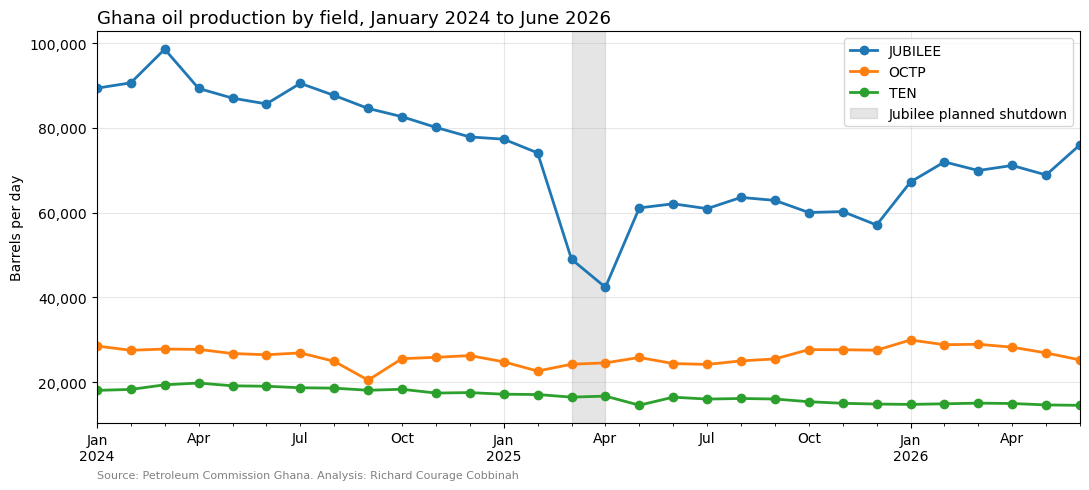

In [51]:
import matplotlib.pyplot as plt
os.makedirs("charts", exist_ok=True)

pivot = prod_full.pivot_table(index="month", columns="field", values="oil_bbl_d")
ax = pivot.plot(figsize=(11, 5), marker="o", linewidth=2)
ax.axvspan(pd.Timestamp("2025-03-01"), pd.Timestamp("2025-04-30"), color="grey", alpha=0.2, label="Jubilee planned shutdown")
ax.set_title("Ghana oil production by field, January 2024 to June 2026", fontsize=13, loc="left")
ax.set_ylabel("Barrels per day")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(alpha=0.3)
ax.legend(title="")
ax.text(0, -0.14, "Source: Petroleum Commission Ghana. Analysis: Richard Courage Cobbinah", transform=ax.transAxes, fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("charts/01_oil_production_by_field.png", dpi=200)
plt.show()

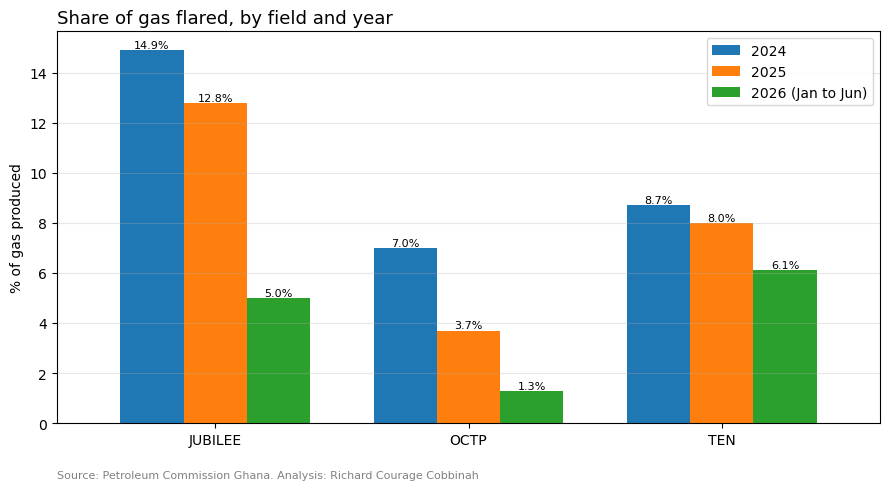

In [52]:
fl = gas["flared_pct"].unstack("year")
fl = fl.rename(columns={2024: "2024", 2025: "2025", 2026: "2026 (Jan to Jun)"})
ax = fl.plot(kind="bar", figsize=(9, 5), width=0.75)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", fontsize=8)
ax.set_title("Share of gas flared, by field and year", fontsize=13, loc="left")
ax.set_ylabel("% of gas produced")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="")
plt.xticks(rotation=0)
ax.text(0, -0.14, "Source: Petroleum Commission Ghana. Analysis: Richard Courage Cobbinah", transform=ax.transAxes, fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("charts/02_flare_share_by_field.png", dpi=200)
plt.show()

group
VITOL                  8.54
ENI                   10.59
GNPC AND STATE        23.84
KOSMOS                26.70
TULLOW AND PETROSA    34.99
Total million barrels: 104.67


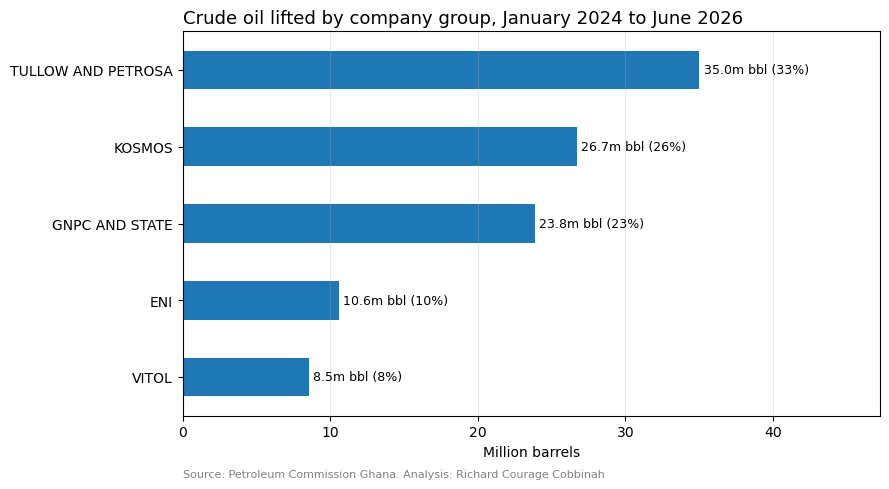

In [53]:
lg = lifts_full.groupby("group")["barrels"].sum().sort_values()
share = lg / lg.sum() * 100
print((lg / 1e6).round(2).to_string())
print("Total million barrels:", round(lg.sum() / 1e6, 2))

ax = (lg / 1e6).plot(kind="barh", figsize=(9, 5), color="#1f77b4")
for i, (v, s) in enumerate(zip(lg / 1e6, share)):
    ax.text(v + 0.3, i, f"{v:,.1f}m bbl ({s:.0f}%)", va="center", fontsize=9)
ax.set_xlim(0, (lg / 1e6).max() * 1.35)
ax.set_title("Crude oil lifted by company group, January 2024 to June 2026", fontsize=13, loc="left")
ax.set_xlabel("Million barrels")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
ax.text(0, -0.16, "Source: Petroleum Commission Ghana. Analysis: Richard Courage Cobbinah", transform=ax.transAxes, fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("charts/03_liftings_by_group.png", dpi=200)
plt.show()

MILLION BARRELS LIFTED, FIELD BY GROUP
group      ENI  GNPC AND STATE  KOSMOS  TULLOW AND PETROSA  VITOL
field                                                            
JUBILEE   0.00           16.16   23.77               26.45   0.00
OCTP     10.59            4.70    0.00                0.00   8.54
TEN       0.00            2.98    2.94                8.54   0.00



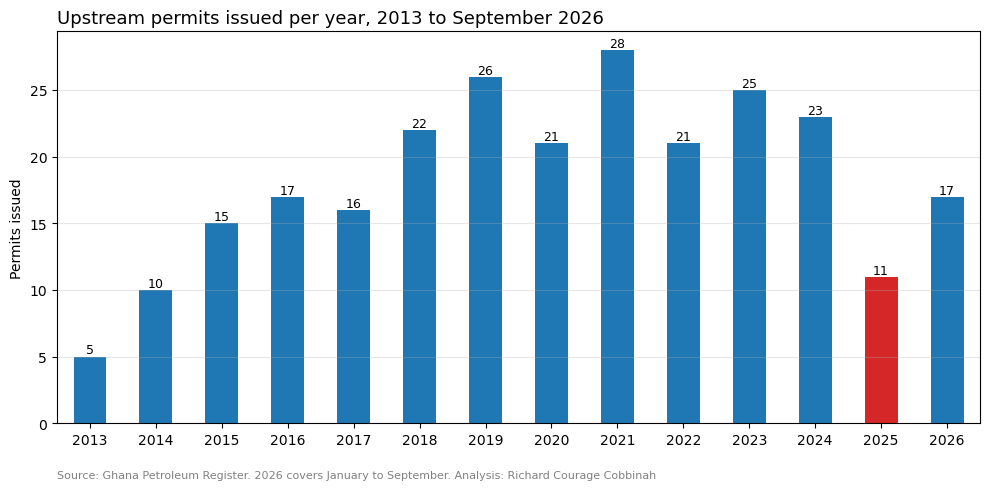

In [54]:
xt = pd.crosstab(lifts_full["field"], lifts_full["group"], values=lifts_full["barrels"], aggfunc="sum").fillna(0) / 1e6
print("MILLION BARRELS LIFTED, FIELD BY GROUP")
print(xt.round(2).to_string())
print()

py = permit_level["start_date"].dt.year.value_counts().sort_index()
py.index = py.index.astype(int)
colors = ["#d62728" if y == 2025 else "#1f77b4" for y in py.index]
ax = py.plot(kind="bar", figsize=(10, 5), color=colors)
ax.bar_label(ax.containers[0], fontsize=9)
ax.set_title("Upstream permits issued per year, 2013 to September 2026", fontsize=13, loc="left")
ax.set_ylabel("Permits issued")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
ax.text(0, -0.14, "Source: Ghana Petroleum Register. 2026 covers January to September. Analysis: Richard Courage Cobbinah", transform=ax.transAxes, fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("charts/04_permits_per_year.png", dpi=200)
plt.show()

In [57]:
dq = pd.DataFrame([
    ["Production", "Asterisks on March and April 2026 rows with no explanatory note", "Web table, Jubilee", 2, "Flag kept in shutdown_flag, cause unknown"],
    ["Production", "Unlabelled extra column repeating oil output", "TEN 2026 web table, April to June", 3, "Column dropped"],
    ["Production", "Same gas flow reported in MMscf/d in one year and MMscf in another", "TEN gas imported from Jubilee, 2024 against 2025", 24, "Jubilee export figures used instead"],
    ["Production", "Same gas flow labelled as import in one source and export in another", "Jubilee 2026 web against 2024 and 2025 Excel", 6, "Mapped to export_to_ten for Jubilee"],
    ["Production", "Spelling and spacing errors in column headers", "Asssociated, Lifiting, double spaces", 6, "Standard column names applied"],
    ["Production", "Data published about three months behind", "July to September 2026 blank on 25 September 2026", 9, "None, noted as lag"],
    ["Production", "2024 file served from a page address labelled 2023", "download/2023-fields-production-data-2", 1, "File fingerprint checked, contents differ from 2025"],
    ["Liftings", "18 spellings for 8 lifting entities", "TGL AND PETROSA, Tullow Ghana Limited & PetroSA", 90, "Keyword mapping to party and group"],
    ["Liftings", "OCTP cargo volumes carry decimals, other fields use whole barrels", "9,425,948.01", 10, "None, noted"],
    ["Operators", "Operator names published only as logo images", "tullow.png, eni.png", 14, "Names mapped from image file names"],
    ["Operators", "Operators page and permit register disagree on active operators", "5 listed operators with no active permit", 5, "None, flagged for follow-up"],
    ["Permits", "Public register blocks automated access and offers no bulk download", "Cloudflare check, 10 rows per page", 300, "Exported through browser table controls"],
    ["Permits", "Missing start or end dates", "Kosmos PC/0010066/A/04-14R", 6, "1 start filled from twin row, rest left blank"],
    ["Permits", "Year typed wrongly, end date before start date", "PC/013/E&P/04-15R start 2025, should be 2015", 5, "Corrected using issue date in permit number"],
    ["Permits", "Exact duplicate rows", "Tullow PC/000057/A/04-13", 5, "Duplicates removed"],
    ["Permits", "Same permit carries different dates in different rows", "Kosmos PC/0010066/A/04-14R", 2, "Start date filled from twin row"],
    ["Permits", "Permit type spelled three ways and purpose text in type field", "Exploration & Production Permit", 8, "Standard type names applied"],
    ["Permits", "38 contractor name spellings for 25 company groups", "Lukoil under 4 spellings", 261, "Keyword mapping to group"],
    ["Permits", "Main operator shows no active permit", "Tullow, 0 of 31 permits active", 31, "None, flagged for follow-up"],
    ["Gas balance", "About 1% of OCTP gas unaccounted every year", "4,530 MMscf, Jan 2024 to Jun 2026", 30, "None, flagged for follow-up"],
    ["Gas balance", "Jubilee to TEN gas transfers recorded inconsistently", "TEN balance 2025, October closes, other months over-correct", 4, "None, flagged for follow-up"],
], columns=["dataset", "issue", "example", "rows_affected", "action_taken"])

dq.index = dq.index + 1
dq.index.name = "id"
dq.to_csv("clean/data_quality_log.csv")
print("Issues logged:", len(dq))
print(dq.groupby("dataset").size().to_string())

Issues logged: 21
dataset
Gas balance    2
Liftings       2
Operators      2
Permits        8
Production     7


In [58]:
%pip install pdfplumber

Note: you may need to restart the kernel to use updated packages.


In [59]:
from io import StringIO
import os, re
import requests
import pandas as pd
import pdfplumber
from bs4 import BeautifulSoup

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

REP_URL = "https://petrocom.gov.gh/reports/"
r_rep = requests.get(REP_URL, headers=HEADERS, timeout=30)
print("Page status:", r_rep.status_code)

soup_rep = BeautifulSoup(r_rep.text, "html.parser")
a = soup_rep.find("a", attrs={"data-downloadurl": True})
pdf_url = a["data-downloadurl"]
print("Link:", pdf_url)

r_pdf = requests.get(pdf_url, headers=dict(HEADERS, Referer=REP_URL), timeout=120)
print("File status:", r_pdf.status_code, "| type:", r_pdf.headers.get("Content-Type"), "| KB:", round(len(r_pdf.content) / 1024, 1))

with open("raw/GUPBO_2026.pdf", "wb") as f:
    f.write(r_pdf.content)

with pdfplumber.open("raw/GUPBO_2026.pdf") as pdf:
    print("Pages:", len(pdf.pages))
    for i, page in enumerate(pdf.pages):
        n_tables = len(page.find_tables())
        if n_tables:
            first_line = (page.extract_text() or "").strip().split("\n")[0][:70]
            print("Page", i + 1, "| tables:", n_tables, "|", first_line)

Page status: 200
Link: https://petrocom.gov.gh/download/gupbo-report-2026/?wpdmdl=24422&refresh=6ab681c7c52f71790345671
File status: 200 | type: application/pdf | KB: 2009.6
Pages: 51
Page 1 | tables: 1 | GHANA UPSTREAM PETROLEUM
Page 10 | tables: 1 | OUTLOOK - EXPLORATION
Page 13 | tables: 1 | OUTLOOK- DEVELOPMENT,
Page 23 | tables: 1 | ECONOMIC
Page 27 | tables: 1 | The graph shows the random walk of crude oil prices in 2025:
Page 29 | tables: 1 | Table 2: Price Support Factors
Page 30 | tables: 1 | OUTLOOK: LEGISLATIVE AND
Page 33 | tables: 1 | OUTLOOK- LOCAL CONTENT
Page 37 | tables: 1 | Table 3 : Annual Procurement Forecast: ENI
Page 38 | tables: 1 | Table 4 : Annual Procurement Forecast: TULLOW
Page 39 | tables: 1 | Logistics: Cargo Carrying Logistics: Cargo Competitive Q4 2026 36 Mont
Page 40 | tables: 1 | Table 5 : Annual Procurement Forecast: OPCO
Page 41 | tables: 1 | Table 6 : Annual Procurement Forecast: MODEC
Page 42 | tables: 1 | Valves Replacement of various valves Compe

In [60]:
with pdfplumber.open("raw/GUPBO_2026.pdf") as pdf:
    for p in [10, 13]:
        tbl = pdf.pages[p - 1].extract_table()
        df = pd.DataFrame(tbl[1:], columns=tbl[0])
        df = df.replace(r"\s+", " ", regex=True)
        print("PAGE", p, "| shape:", df.shape)
        print(df.to_string())
        print()

PAGE 10 | shape: (2, 2)
                                     None
0  OUTLOOK - EXPLORATION ACTIVITIES  None
1                              None     7

PAGE 13 | shape: (2, 2)
                                                    None
0  OUTLOOK- DEVELOPMENT, PRODUCTION AND OPERATIONS  None
1                                             None    10



In [61]:
with pdfplumber.open("raw/GUPBO_2026.pdf") as pdf:
    texts = {i + 1: (pg.extract_text() or "") for i, pg in enumerate(pdf.pages)}

with open("raw/GUPBO_2026_text.txt", "w", encoding="utf-8") as f:
    for p, t in texts.items():
        f.write(f"\n\n===== PAGE {p} =====\n{t}")

print("Characters per page, pages 10 to 22:")
for p in range(10, 23):
    print("Page", p, ":", len(texts[p]))
print()
print("===== PAGE 11 =====")
print(texts[11][:2500])

Characters per page, pages 10 to 22:
Page 10 : 88
Page 11 : 2913
Page 12 : 1945
Page 13 : 104
Page 14 : 3455
Page 15 : 3428
Page 16 : 2970
Page 17 : 879
Page 18 : 96
Page 19 : 2389
Page 20 : 2441
Page 21 : 2373
Page 22 : 1187

===== PAGE 11 =====
CAPE THREE POINTS BLOCK 4 (ENI GHANA EXPLORATION & PRODUCTION LIMITED)
Following the completion of the appraisal programme for the Akoma and Eban Discoveries, Eni and its
Partners submitted an appraisal report and declared the Akoma and Eban Discoveries commercial in July
2025.
The Contractor is expected to submit a Plan of Development and Operations (PDO) to the Minister for Energy
and Green Transition by mid- 2026 for approval to develop and produce the Akoma and Eban Discoveries.
In addition, Eni, following the completion of further geological and geophysical studies for the Aprokuma
Discovery is planning to drill a well, Aprokuma-2A to appraise the discovery and determine its commerciality.
The Aprokuma-2A is planned for drilling in Septem

In [62]:
ops.loc[ops["logo"] == "planet.jpg", "operator"] = "Planet One Oil and Energy"
ops.to_csv("clean/operators_2026.csv", index=False)

MONTHS = "January|February|March|April|May|June|July|August|September|October|November|December"
date_pat = re.compile(rf"((?:mid-?\s*|end of\s+|by\s+)?(?:Q[1-4]\s*|(?:{MONTHS}),?\s*)?20\d\d)", re.I)
head_pat = re.compile(r"^([A-Z0-9][A-Z0-9 &\-/,.']+)\s*\(([^)]+)\)\s*$")

sections = []
for p in [11, 12, 14, 15, 16, 17, 19, 20, 21, 22]:
    for line in texts[p].split("\n"):
        m = head_pat.match(line.strip())
        if m:
            sections.append({"page": p, "block": m.group(1).strip(), "company": m.group(2).strip(), "text": ""})
        elif sections:
            sections[-1]["text"] += " " + line.strip()

plans = pd.DataFrame(sections)
plans["section"] = plans["page"].apply(lambda p: "Exploration" if p < 13 else "Development and production")
plans["dates_mentioned"] = plans["text"].apply(lambda t: "; ".join(dict.fromkeys(d.strip() for d in date_pat.findall(t))))
plans["words"] = plans["text"].str.split().str.len()
plans.to_csv("clean/outlook_2026_block_plans.csv", index=False)

print("Sections found:", len(plans))
print(plans[["page", "section", "block", "company", "dates_mentioned"]].to_string())

Sections found: 10
   page      section                             block                                     company                                                                                                                      dates_mentioned
0    11  Exploration         CAPE THREE POINTS BLOCK 4  ENI GHANA EXPLORATION & PRODUCTION LIMITED                                                                                                July 2025; mid- 2026; September, 2026
1    11  Exploration       EXPANDED SHALLOW WATER TANO                                 BASE ENERGY                                                                                                                              Q4 2026
2    11  Exploration                CENTRAL TANO BLOCK    AMNI INTERNATIONAL PETROLEUM DEVELOPMENT                                                                                                                              Q1 2027
3    11  Exploration  DEEPWATER CAPE THREE POINTS WES

In [63]:
for p in [14, 19]:
    print("===== PAGE", p, "=====")
    for n, line in enumerate(texts[p].split("\n")[:15]):
        print(n, "|", line)
    print()

===== PAGE 14 =====
0 | PECAN ENERGIES
1 | Pecan Energies’ Plan of Development (PoD) for the Pecan field was approved by the Minister of Energy (MoE)
2 | in June 2023. Post this approval, Pecan Energies has worked towards securing Final Investment Decision
3 | (FID) and commence development activities including the contracting or procurement of items.
4 | The development concept for the Pecan field considers the Water Alternating Gas (WAG) recovery and
5 | deployment of existing Floating Production Storage and Offloading (FPSO) Dhirubhai 1 which will undergo
6 | modification to best fit the requirements of the field. The PoD also considers additional development studies
7 | to be carried out for the other discoveries within the Deep Water Tano Cape Three Points (DWT/CTP) license
8 | area.
9 | In 2025, negotiations commenced between the Government of Ghana, Pecan Energies and Shell for possible
10 | farm in by Shell. In this regard, Shell submitted a proposal to commence discussions on 

In [64]:
def is_heading(s):
    if head_pat.match(s):
        return True
    return bool(s) and s == s.upper() and bool(re.search(r"[A-Z]{3}", s)) and 1 <= len(s.split()) <= 10 and not s.endswith((".", ","))

sections = []
for p in [11, 12, 14, 15, 16, 17, 19, 20, 21, 22]:
    for line in texts[p].split("\n"):
        s = line.strip()
        if is_heading(s):
            m = head_pat.match(s)
            sections.append({
                "page": p,
                "block": m.group(1).strip() if m else s,
                "company": m.group(2).strip() if m else "",
                "text": "",
            })
        elif sections:
            sections[-1]["text"] += " " + s

plans = pd.DataFrame(sections)
plans["section"] = plans["page"].apply(lambda p: "Exploration" if p < 13 else ("Development and production" if p < 18 else "HSE and other"))
plans["dates_mentioned"] = plans["text"].apply(lambda t: "; ".join(dict.fromkeys(d.strip() for d in date_pat.findall(t))))
plans["words"] = plans["text"].str.split().str.len()
plans = plans[plans["words"] >= 5].reset_index(drop=True)
plans.to_csv("clean/outlook_2026_block_plans.csv", index=False)

print("Sections found:", len(plans))
print(plans[["page", "section", "block", "company", "words", "dates_mentioned"]].to_string())

Sections found: 20
    page                     section                                                 block                                     company  words                                   dates_mentioned
0     11                 Exploration                             CAPE THREE POINTS BLOCK 4  ENI GHANA EXPLORATION & PRODUCTION LIMITED    107             July 2025; mid- 2026; September, 2026
1     11                 Exploration                           EXPANDED SHALLOW WATER TANO                                 BASE ENERGY     79                                           Q4 2026
2     11                 Exploration                                    CENTRAL TANO BLOCK    AMNI INTERNATIONAL PETROLEUM DEVELOPMENT     42                                           Q1 2027
3     11                 Exploration                      DEEPWATER CAPE THREE POINTS WEST                    ECO ATLANTIC OIL AND GAS     56                      end of September, 2026; 2026
4     11             

In [65]:
keys = ["2028", "2034", "2036", "2040", "2046", "March 2026", "August 2026"]
for idx in [11, 12, 14, 16]:
    row = plans.loc[idx]
    print("=====", row["block"], "=====")
    sents = re.split(r"(?<=[.!?])\s+", row["text"])
    for s in sents:
        if any(k in s for k in keys):
            print("-", s.strip())
    print()

===== ENI EXPLORATION AND PRODUCTION GHANA LIMITED =====
- The Parties are also requesting for an extension of the OCTP Petroleum Agreement to 2046.
- Under the ISP the OCTP partners will upgrade the OCTP facilities and increase gas production from 246 MMscfd to 350 MMscfd by 2028 through the development of Gye Nyame, the installation of a booster compressor and of a new non-associated gas system on the FPSO.

===== TULLOW GHANA LIMITED =====
- TGL will continue with the OBN data processing in 2026 in support for wells location for the future wells., TGL will also continue with the Jubilee Life Extension project in support of extension of the Petroleum Agreement up to 2040.
- TGL and other Parties to the Deepwater Tano (DWT) and West Cape Three Points (“WCTP”) Contract Areas have signed agreement with the State to amend the Petroleum Agreements related to the two licenses which are due to expire on 21st July 2034 This is in recognition of the fact that production from the Contract Area

In [66]:
proc_parts = []
with pdfplumber.open("raw/GUPBO_2026.pdf") as pdf:
    for p in range(37, 46):
        for tbl in pdf.pages[p - 1].extract_tables():
            cols = [re.sub(r"\s+", " ", str(c)).strip() for c in tbl[0]]
            df = pd.DataFrame(tbl[1:], columns=cols)
            df["page"] = p
            proc_parts.append(df)
            print("Page", p, "| shape:", df.shape, "| columns:", cols)

print()
print(proc_parts[0].head(8).to_string())

Page 37 | shape: (18, 6) | columns: ['', 'None', 'None', 'None', 'None']
Page 38 | shape: (20, 6) | columns: ['', '', 'TULLOW', '', '']
Page 39 | shape: (13, 6) | columns: ['Safety Equipment Maintenance', 'Safety Equipment Maintenance', 'Competitive Tender', 'Q3 2026', '36 Months']
Page 40 | shape: (23, 6) | columns: ['', '', '', '', '']
Page 41 | shape: (14, 6) | columns: ['MODEC', 'None', 'None', 'None', 'None']
Page 42 | shape: (10, 6) | columns: ['Valves', 'Replacement of various valves installed on the FPSO, and valves required for modification projects.', 'Competitive Tender', 'Q1 2026', 'TBC']
Page 43 | shape: (15, 6) | columns: ['YINSON', 'None', 'None', 'None', 'None']
Page 44 | shape: (9, 6) | columns: ['GOS', 'None', 'None', 'None', 'None']
Page 45 | shape: (10, 6) | columns: ['GNPC', 'None', 'None', 'None', 'None']

                                                                                                                                              None              

In [67]:
PAGE_CO = {37: "ENI", 38: "TULLOW", 39: "TULLOW", 40: "OPCO", 41: "MODEC", 42: "MODEC", 43: "YINSON", 44: "GOS", 45: "GNPC"}
CO_NAMES = set(PAGE_CO.values())

def clean_cell(x):
    if x is None:
        return ""
    s = str(x).replace("-\n", "").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return "" if s == "None" else s

records = []
with pdfplumber.open("raw/GUPBO_2026.pdf") as pdf:
    for p in range(37, 46):
        for tbl in pdf.pages[p - 1].extract_tables():
            for row in tbl:
                cells = [clean_cell(c) for c in row][:5]
                cells += [""] * (5 - len(cells))
                filled = [c for c in cells if c]
                if not filled:
                    continue
                if len(filled) == 1 and filled[0].upper() in CO_NAMES:
                    continue
                if "PROCUREMENT ITEM" in cells[0].upper():
                    continue
                records.append([PAGE_CO[p], p] + cells)

proc = pd.DataFrame(records, columns=["company", "page", "item", "scope", "method", "start", "duration"])

def std_method(m):
    m = m.lower()
    if "compet" in m:
        return "Competitive tender"
    if "sole" in m or "single" in m:
        return "Single or sole source"
    return m if m else "Not stated"

proc["method_std"] = proc["method"].apply(std_method)
logi = r"logistic|transport|haulage|freight|shipment|customs|cargo|vessel|marine|warehous|truck|clearing|forward"
proc["logistics_related"] = (proc["item"] + " " + proc["scope"]).str.contains(logi, case=False, regex=True)
proc.to_csv("clean/procurement_forecast_2026.csv", index=False)

print("Procurement lines:", len(proc))
print()
print(proc.groupby("company").size().to_string())
print()
print(proc["method_std"].value_counts().to_string())
print()
print("LOGISTICS-RELATED LINES:", proc["logistics_related"].sum())
print(proc.loc[proc["logistics_related"], ["company", "item", "method_std", "start", "duration"]].to_string())

Procurement lines: 131

company
ENI       16
GNPC      10
GOS        9
MODEC     25
OPCO      22
TULLOW    34
YINSON    15

method_std
Competitive tender       100
Single or sole source     27
restricted tendering       4

LOGISTICS-RELATED LINES: 20
    company                                                                                                   item             method_std    start   duration
0       ENI                                    Provision of Marine Auditing Service and Marine Engineering Support  Single or sole source  Q1 2026  36 Months
1       ENI                                                               Material Handling, Shipment, Ff, Customs     Competitive tender  Q1 2026  24 Months
9       ENI                                                      Marine Fleet to Support Drilling Activities (PSV)     Competitive tender  Q1 2026   3 Months
13      ENI                             Provision of Surf Offshore Transportation & Installation - Gye Nyame Field   

In [68]:
txt = proc["item"] + " " + proc["scope"]
logi2 = r"logistic|transport|haulage|freight|shipment|customs|cargo handling|marine vessel|marine fleet|warehous|truck|clearing|\bports?\b|harbour|crane|forklift|\bfuel\b|helicopter"
proc["logistics_related"] = txt.str.contains(logi2, case=False, regex=True) & ~txt.str.contains("pressure vessel", case=False)
proc["dup_line"] = proc.duplicated(["company", "item", "scope", "start", "duration"], keep=False)

q = proc["start"].str.extract(r"Q([1-4])\s*(20\d\d)")
proc["start_q"] = pd.to_numeric(q[1]) * 10 + pd.to_numeric(q[0])
proc["open_from_q3_2026"] = proc["start_q"] >= 20263
proc.to_csv("clean/procurement_forecast_2026.csv", index=False)

print("Repeated lines:", proc["dup_line"].sum())
print(proc.loc[proc["dup_line"], ["company", "item", "start"]].to_string())
print()
print("Logistics-related lines:", proc["logistics_related"].sum())
print()
up = proc[proc["logistics_related"] & proc["open_from_q3_2026"]]
print("LOGISTICS LINES OPENING Q3 2026 OR LATER:", len(up))
print(up[["company", "item", "method_std", "start", "duration"]].drop_duplicates().to_string())

Repeated lines: 18
   company                                                     item    start
21  TULLOW               Logistics: Ports & Harbour Agency Services  Q4 2026
22  TULLOW                             Chemicals (Commodity Supply)  Q2 2026
23  TULLOW               Pumps & Emergency Generator & HV/LV Motors  Q2 2026
24  TULLOW                     Offshore Catering and Hotel Services  Q2 2026
25  TULLOW           Chemicals (Speciality and Management Services)  Q2 2026
26  TULLOW  Contingent workforce and recruitment outsource services  Q1 2027
27  TULLOW               Logistics: Ports & Harbour Agency Services  Q4 2026
29  TULLOW                             Chemicals (Commodity Supply)  Q2 2026
30  TULLOW               Pumps & Emergency Generator & HV/LV Motors  Q2 2026
31  TULLOW                     Offshore Catering and Hotel Services  Q2 2026
32  TULLOW           Chemicals (Speciality and Management Services)  Q2 2026
33  TULLOW  Contingent workforce and recruitment outsourc

In [69]:
print("Repeated rows by page:")
print(proc.loc[proc["dup_line"]].groupby("page").size().to_string())
print()

proc_u = proc.drop_duplicates(["company", "item", "scope", "start", "duration"]).copy()
proc_u.to_csv("clean/procurement_forecast_2026.csv", index=False)
print("Unique procurement lines:", len(proc_u))
print(proc_u.groupby("company").size().to_string())
print()
print((proc_u["method_std"].value_counts(normalize=True) * 100).round(1).to_string())
print()

new_issues = pd.DataFrame([
    ["Operators", "Same blocks under three operator names across sources", "OPCO on operators page and Outlook, Blue Star in permit register", 2, "Flagged for follow-up"],
    ["Operators", "Operators page omits blocks covered in the Outlook report", "Voltaian Basin, South Deepwater Tano", 2, "Flagged for follow-up"],
    ["Outlook report", "Procurement lines repeated in Tullow forecast", "Ports and Harbour Agency Services listed 3 times", 10, "Duplicates removed"],
    ["Outlook report", "Section title boxes read as tables by PDF tools", "Pages 10 and 13", 2, "Text parsed by headings instead"],
], columns=["dataset", "issue", "example", "rows_affected", "action_taken"])

dq = pd.concat([dq, new_issues], ignore_index=True)
dq.index = dq.index + 1
dq.index.name = "id"
dq.to_csv("clean/data_quality_log.csv")
print("Issues logged:", len(dq))

Repeated rows by page:
page
38    13
39     5

Unique procurement lines: 121
company
ENI       16
GNPC      10
GOS        9
MODEC     25
OPCO      22
TULLOW    24
YINSON    15

method_std
Competitive tender       75.2
Single or sole source    21.5
restricted tendering      3.3

Issues logged: 25


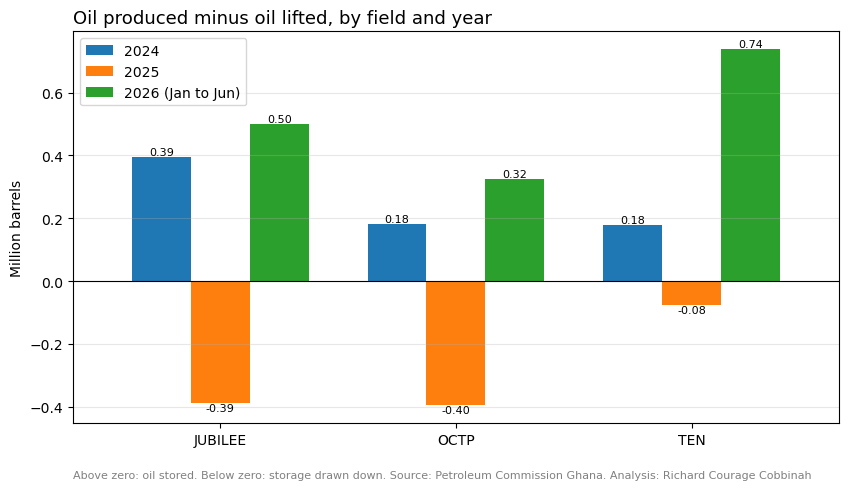

In [70]:
rp = prod_full.groupby(["field", "year"])["oil_bbl_month"].sum()
rl = lifts_full.groupby(["field", "year"])["barrels"].sum()
rf = pd.DataFrame({"produced": rp, "lifted": rl}).fillna(0)
rf["stored_mbbl"] = (rf["produced"] - rf["lifted"]) / 1e6
rf.round(2).to_csv("clean/reconciliation_2024_2026H1.csv")

st = rf["stored_mbbl"].unstack("year").rename(columns={2024: "2024", 2025: "2025", 2026: "2026 (Jan to Jun)"})
ax = st.plot(kind="bar", figsize=(9, 5), width=0.75)
ax.axhline(0, color="black", linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
ax.set_title("Oil produced minus oil lifted, by field and year", fontsize=13, loc="left")
ax.set_ylabel("Million barrels")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="")
plt.xticks(rotation=0)
ax.text(0, -0.14, "Above zero: oil stored. Below zero: storage drawn down. Source: Petroleum Commission Ghana. Analysis: Richard Courage Cobbinah", transform=ax.transAxes, fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("charts/05_storage_cycle.png", dpi=200)
plt.show()

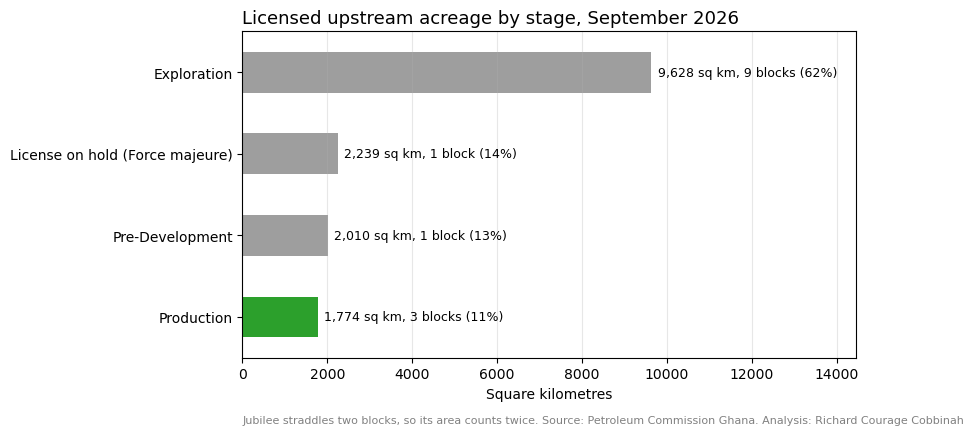

In [73]:
ac = ops.groupby("stage").agg(blocks=("contract_area", "count"), area=("area_sq_km", "sum")).sort_values("area")
share = ac["area"] / ac["area"].sum() * 100
colors = ["#2ca02c" if s == "Production" else "#9e9e9e" for s in ac.index]

ax = ac["area"].plot(kind="barh", figsize=(9, 4.5), color=colors)
for i, (a, b, s) in enumerate(zip(ac["area"], ac["blocks"], share)):
    label = "block" if b == 1 else "blocks"
    ax.text(a + 150, i, f"{a:,.0f} sq km, {b} {label} ({s:.0f}%)", va="center", fontsize=9)
ax.set_xlim(0, ac["area"].max() * 1.5)
ax.set_title("Licensed upstream acreage by stage, September 2026", fontsize=13, loc="left")
ax.set_xlabel("Square kilometres")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
ax.text(0, -0.2, "Jubilee straddles two blocks, so its area counts twice. Source: Petroleum Commission Ghana. Analysis: Richard Courage Cobbinah", transform=ax.transAxes, fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("charts/06_acreage_by_stage.png", dpi=200)
plt.show()

In [74]:
import shutil
pkg = "kaggle_package"
if os.path.exists(pkg):
    shutil.rmtree(pkg)
shutil.copytree("clean", pkg)
shutil.copytree("charts", os.path.join(pkg, "charts"))
zip_path = shutil.make_archive("ghana_upstream_petroleum_2024_2026", "zip", pkg)

print("Zip:", zip_path)
print("KB:", round(os.path.getsize(zip_path) / 1024, 1))
print()
for root, dirs, files in os.walk(pkg):
    for f in sorted(files):
        print(os.path.join(root, f).replace(pkg + os.sep, ""))

Zip: C:\Users\HP\ghana_upstream_petroleum_2024_2026.zip
KB: 468.8

data_quality_log.csv
gas_balance_by_field_year.csv
gas_use_by_field_year.csv
liftings_2024_2025.csv
liftings_2024_2026H1.csv
operators_2026.csv
outlook_2026_block_plans.csv
permits_by_company.csv
permits_rows_clean.csv
permits_unique.csv
procurement_forecast_2026.csv
production_2024_2025.csv
production_2024_2026H1.csv
reconciliation_2024_2025.csv
reconciliation_2024_2026H1.csv
charts\01_oil_production_by_field.png
charts\02_flare_share_by_field.png
charts\03_liftings_by_group.png
charts\04_permits_per_year.png
charts\05_storage_cycle.png
charts\06_acreage_by_stage.png


In [75]:
for old in ["production_2024_2025.csv", "liftings_2024_2025.csv", "reconciliation_2024_2025.csv"]:
    os.remove(os.path.join(pkg, old))
zip_path = shutil.make_archive("ghana_upstream_petroleum_2024_2026", "zip", pkg)
print("KB:", round(os.path.getsize(zip_path) / 1024, 1))
print("Files:", sum(len(f) for _, _, f in os.walk(pkg)))

KB: 463.1
Files: 18
